In [1]:
# 1. import libraries

import os
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 2. set paths

patients_path = r"E:\apply\journal publication\tnbc-diffusion\data\patients\ispy2"
save_path = r"E:\apply\journal publication\tnbc-diffusion\data\processed"
figures_path = r"E:\apply\journal publication\tnbc-diffusion\outputs\figures"

patient_list = sorted(os.listdir(patients_path))
print("total patients:", len(patient_list))
print(patient_list)

total patients: 16
['ISPY2-164468', 'ISPY2-196024', 'ISPY2-208303', 'ISPY2-252748', 'ISPY2-489504', 'ISPY2-502486', 'ISPY2-535779', 'ISPY2-564234', 'ISPY2-578975', 'ISPY2-622315', 'ISPY2-625854', 'ISPY2-697098', 'ISPY2-727804', 'ISPY2-829491', 'ISPY2-910706', 'ISPY2-934906']


In [7]:
# 3. function to find t0 study folder

def find_t0_folder(patient_path):
    for folder in os.listdir(patient_path):
        folder_path = os.path.join(patient_path, folder)
        for series in os.listdir(folder_path):
            series_path = os.path.join(folder_path, series)
            dicom_files = os.listdir(series_path)
            if len(dicom_files) == 0:
                continue
            ds = pydicom.dcmread(os.path.join(series_path, dicom_files[0]))
            if hasattr(ds, "StudyDescription") and "T0" in str(ds.StudyDescription):
                return folder_path
    return None

In [8]:
# 4. function to find mask and dce series inside a study folder

def find_series(study_path):
    mask_folder = None
    dce_folder = None
    for series_folder in os.listdir(study_path):
        series_path = os.path.join(study_path, series_folder)
        dicom_files = os.listdir(series_path)
        if len(dicom_files) == 0:
            continue
        ds = pydicom.dcmread(os.path.join(series_path, dicom_files[0]))
        desc = ds.SeriesDescription.lower()
        if "analysis mask" in desc:
            mask_folder = series_path
        if "original dce" in desc:
            dce_folder = series_path
    return mask_folder, dce_folder

In [9]:
# 5. function to extract tumor mask from segmentation dicom

def extract_tumor_mask(mask_path):
    mask_file = os.path.join(mask_path, os.listdir(mask_path)[0])
    ds = pydicom.dcmread(mask_file)
    mask_array = ds.pixel_array
    unique_vals = np.unique(mask_array)
    best_val = None
    best_count = 0
    for val in unique_vals:
        if val == 0:
            continue
        count = np.sum(mask_array == val)
        if count < 50000 and count > best_count:
            best_count = count
            best_val = val
    tumor_mask = (mask_array == best_val).astype(np.uint8)
    return tumor_mask, ds, best_val

In [10]:
# 6. function to compute tumor volume

def compute_volume(tumor_mask, ds):
    try:
        shared = ds.SharedFunctionalGroupsSequence[0]
        pixel_spacing = float(shared.PixelMeasuresSequence[0].PixelSpacing[0])
        slice_thickness = float(shared.PixelMeasuresSequence[0].SliceThickness)
    except Exception:
        pixel_spacing = 0.7031
        slice_thickness = 2.2
    voxel_volume_cc = (pixel_spacing * pixel_spacing * slice_thickness) / 1000
    tumor_volume_cc = np.sum(tumor_mask) * voxel_volume_cc
    return round(tumor_volume_cc, 4), pixel_spacing, slice_thickness

In [11]:
# 7. function to load and reshape dce array

def load_dce(dce_path, n_slices):
    dce_files = sorted(os.listdir(dce_path))
    dce_slices = []
    for f in dce_files:
        ds = pydicom.dcmread(os.path.join(dce_path, f))
        dce_slices.append(ds.pixel_array)
    dce_array = np.array(dce_slices)
    n_timeframes = dce_array.shape[0] // n_slices
    dce_4d = dce_array.reshape(n_timeframes, n_slices, dce_array.shape[1], dce_array.shape[2])
    return dce_4d

In [12]:
# 8. process all patients in a loop

results = []

for patient_id in patient_list:
    print("processing:", patient_id)
    patient_path = os.path.join(patients_path, patient_id)

    t0_path = find_t0_folder(patient_path)
    if t0_path is None:
        print("  t0 not found for:", patient_id)
        results.append({"patient_id": patient_id, "status": "t0 not found"})
        continue

    mask_path, dce_path = find_series(t0_path)
    if mask_path is None or dce_path is None:
        print("  mask or dce not found for:", patient_id)
        results.append({"patient_id": patient_id, "status": "series not found"})
        continue

    tumor_mask, ds, mask_val = extract_tumor_mask(mask_path)
    tumor_volume, pixel_spacing, slice_thickness = compute_volume(tumor_mask, ds)

    n_slices = tumor_mask.shape[0]
    dce_4d = load_dce(dce_path, n_slices)

    pid = patient_id.replace("ISPY2-", "")
    np.save(os.path.join(save_path, "tumor_mask_" + pid + "_T0.npy"), tumor_mask)
    np.save(os.path.join(save_path, "dce_4d_" + pid + "_T0.npy"), dce_4d)

    results.append({
        "patient_id": patient_id,
        "status": "ok",
        "mask_value": mask_val,
        "tumor_voxels": int(np.sum(tumor_mask)),
        "tumor_volume_cc": tumor_volume,
        "pixel_spacing_mm": pixel_spacing,
        "slice_thickness_mm": slice_thickness,
        "n_slices": n_slices,
        "dce_timeframes": dce_4d.shape[0],
        "dce_shape": str(dce_4d.shape)
    })

    print("  done. volume:", tumor_volume, "cc, dce shape:", dce_4d.shape)

print("finished all patients")

processing: ISPY2-164468
  done. volume: 31.9952 cc, dce shape: (7, 72, 256, 256)
processing: ISPY2-196024
  done. volume: 17.2423 cc, dce shape: (7, 72, 256, 256)
processing: ISPY2-208303
  done. volume: 6.2437 cc, dce shape: (7, 72, 256, 256)
processing: ISPY2-252748
  done. volume: 18.0586 cc, dce shape: (7, 160, 384, 384)
processing: ISPY2-489504
  done. volume: 30.3938 cc, dce shape: (8, 80, 256, 256)
processing: ISPY2-502486
  done. volume: 10.1055 cc, dce shape: (8, 80, 312, 312)
processing: ISPY2-535779
  done. volume: 2.7499 cc, dce shape: (7, 66, 256, 256)
processing: ISPY2-564234
  done. volume: 13.4077 cc, dce shape: (6, 134, 256, 256)
processing: ISPY2-578975
  done. volume: 33.8986 cc, dce shape: (7, 76, 312, 312)
processing: ISPY2-622315
  done. volume: 38.0043 cc, dce shape: (7, 66, 256, 256)
processing: ISPY2-625854
  done. volume: 2.1408 cc, dce shape: (6, 134, 256, 256)
processing: ISPY2-697098
  done. volume: 24.6226 cc, dce shape: (8, 80, 256, 256)
processing: ISPY

In [13]:
# 9. save results summary

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(save_path, "batch_processing_summary.csv"), index=False)

print(results_df[["patient_id", "status", "tumor_volume_cc", "dce_timeframes"]])

      patient_id status  tumor_volume_cc  dce_timeframes
0   ISPY2-164468     ok          31.9952               7
1   ISPY2-196024     ok          17.2423               7
2   ISPY2-208303     ok           6.2437               7
3   ISPY2-252748     ok          18.0586               7
4   ISPY2-489504     ok          30.3938               8
5   ISPY2-502486     ok          10.1055               8
6   ISPY2-535779     ok           2.7499               7
7   ISPY2-564234     ok          13.4077               6
8   ISPY2-578975     ok          33.8986               7
9   ISPY2-622315     ok          38.0043               7
10  ISPY2-625854     ok           2.1408               6
11  ISPY2-697098     ok          24.6226               8
12  ISPY2-727804     ok          24.7735               7
13  ISPY2-829491     ok           5.4458               7
14  ISPY2-910706     ok          40.4583               9
15  ISPY2-934906     ok           5.8216               8


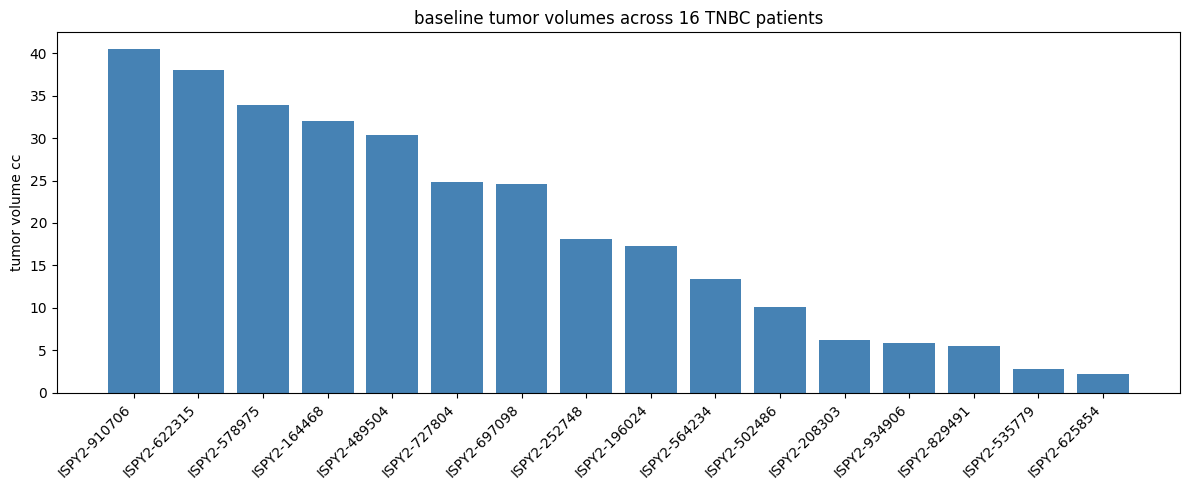

In [14]:
# 10. plot tumor volumes across all patients

ok_df = results_df[results_df["status"] == "ok"].copy()
ok_df = ok_df.sort_values("tumor_volume_cc", ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(ok_df["patient_id"], ok_df["tumor_volume_cc"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("tumor volume cc")
plt.title("baseline tumor volumes across 16 TNBC patients")
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "batch_tumor_volumes.png"), dpi=150)
plt.show()

In [15]:
# 11. merge batch results with clinical tnbc data

clinical_path = r"E:\apply\journal publication\tnbc-diffusion\data\processed\tnbc_patients.csv"
clinical = pd.read_csv(clinical_path)

clinical["patient_id"] = "ISPY2-" + clinical["Patient_ID"].astype(str)

final_df = pd.merge(results_df, clinical, on="patient_id", how="left")

cols = ["patient_id", "status", "tumor_volume_cc", "dce_timeframes", "pCR", "Age_at_Screening", "LD_T0", "SPHERICITY_T0"]
print(final_df[cols])

      patient_id status  tumor_volume_cc  dce_timeframes  pCR  \
0   ISPY2-164468     ok          31.9952               7    0   
1   ISPY2-196024     ok          17.2423               7    0   
2   ISPY2-208303     ok           6.2437               7    1   
3   ISPY2-252748     ok          18.0586               7    1   
4   ISPY2-489504     ok          30.3938               8    1   
5   ISPY2-502486     ok          10.1055               8    0   
6   ISPY2-535779     ok           2.7499               7    0   
7   ISPY2-564234     ok          13.4077               6    1   
8   ISPY2-578975     ok          33.8986               7    1   
9   ISPY2-622315     ok          38.0043               7    0   
10  ISPY2-625854     ok           2.1408               6    1   
11  ISPY2-697098     ok          24.6226               8    1   
12  ISPY2-727804     ok          24.7735               7    1   
13  ISPY2-829491     ok           5.4458               7    0   
14  ISPY2-910706     ok  

In [16]:
# 12. save final merged dataset

final_df.to_csv(os.path.join(save_path, "tnbc_imaging_clinical.csv"), index=False)
print("saved:", len(final_df), "patients")

saved: 16 patients


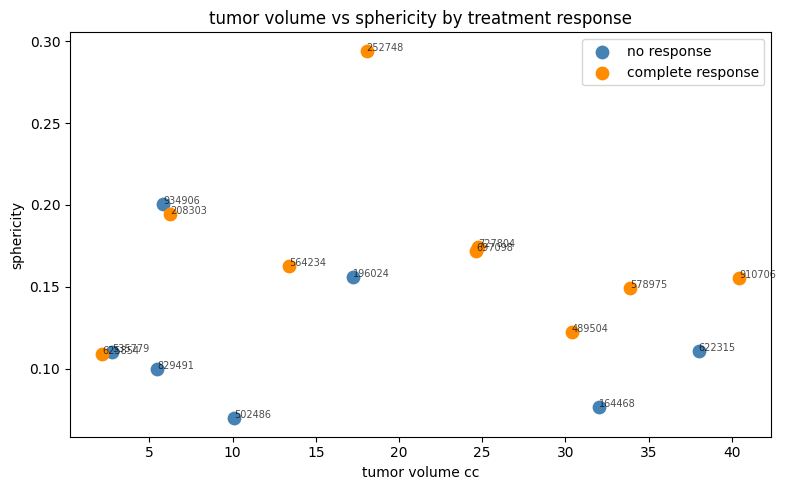

In [17]:
# 13. plot tumor volume by treatment response

responders = final_df[final_df["pCR"] == 1]
non_responders = final_df[final_df["pCR"] == 0]

plt.figure(figsize=(8, 5))
plt.scatter(non_responders["tumor_volume_cc"], non_responders["SPHERICITY_T0"],
            color="steelblue", label="no response", s=80)
plt.scatter(responders["tumor_volume_cc"], responders["SPHERICITY_T0"],
            color="darkorange", label="complete response", s=80)

for idx, row in final_df.iterrows():
    plt.annotate(row["patient_id"].replace("ISPY2-", ""),
                (row["tumor_volume_cc"], row["SPHERICITY_T0"]),
                fontsize=7, alpha=0.7)

plt.xlabel("tumor volume cc")
plt.ylabel("sphericity")
plt.title("tumor volume vs sphericity by treatment response")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "volume_sphericity_response.png"), dpi=300)
plt.show()